In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('C:\\Users\\ferna\\OneDrive\\Downloads\\GitHub\\ml_factorinv')
with open('data/fredapi.txt', 'r') as f: # save file in this location with your fred_api key
    fred_api_key = f.read().strip()

In [9]:
from data.data_load import *

In [10]:
cols = features_short + ['R1M_Usd','date']; print(cols)
data_corr = data_ml[cols]
data_corr = data_corr.groupby('date').corr()['R1M_Usd'].reset_index() # get corr of features with 'R1M_Usd'
data_corr.rename(columns={'level_1': "Factors"},inplace=True) 
data_corr.iloc[[0,1,2,3,-2,-1],]

['Div_Yld', 'Eps', 'Mkt_Cap_12M_Usd', 'Mom_11M_Usd', 'Ocf', 'Pb', 'Vol1Y_Usd', 'R1M_Usd', 'date']


,date,Factors,R1M_Usd
0,2000-01-31,Div_Yld,-0.218878
1,2000-01-31,Eps,-0.268875
2,2000-01-31,Mkt_Cap_12M_Usd,-0.125346
3,2000-01-31,Mom_11M_Usd,0.203169
1822,2018-12-31,Vol1Y_Usd,0.244832
1823,2018-12-31,R1M_Usd,1.000000


#### 1) Correlations

<Axes: xlabel='Factors', ylabel='R1M_Usd'>

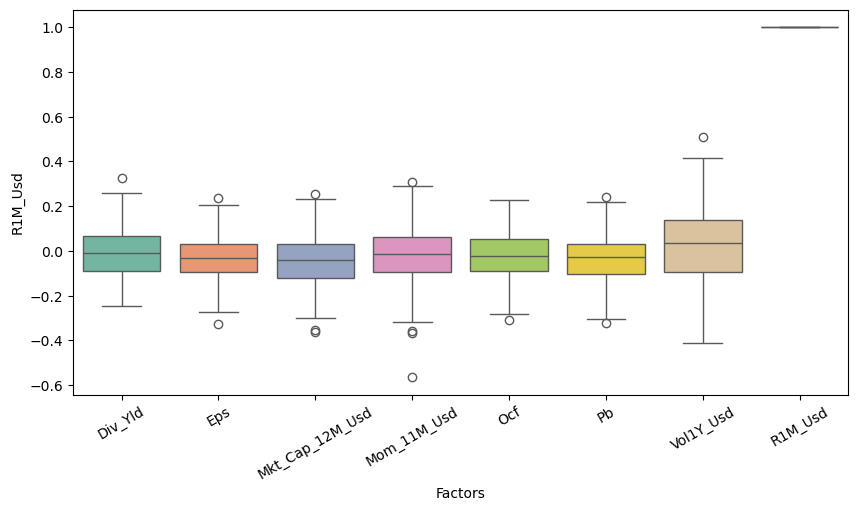

In [11]:
plt.figure(figsize = (10,5))
plt.xticks(rotation = 30)
sns.boxplot(x="Factors",y="R1M_Usd",data=data_corr,hue = 'Factors',palette = 'Set2')

#### 2) Average returns as function of some features

In [12]:
unpivoted_data_ml = pd.melt(data_ml[['R1M_Usd','Mkt_Cap_12M_Usd','Vol1Y_Usd']], id_vars='R1M_Usd') 
unpivoted_data_ml

,R1M_Usd,variable,value
0,0.089,Mkt_Cap_12M_Usd,0.24
1,0.039,Mkt_Cap_12M_Usd,0.24
2,-0.012,Mkt_Cap_12M_Usd,0.25
3,0.174,Mkt_Cap_12M_Usd,0.33
4,-0.106,Mkt_Cap_12M_Usd,0.30
...,...,...,...
536667,-0.029,Vol1Y_Usd,0.34
536668,0.028,Vol1Y_Usd,0.29
536669,0.011,Vol1Y_Usd,0.27
536670,0.045,Vol1Y_Usd,0.26


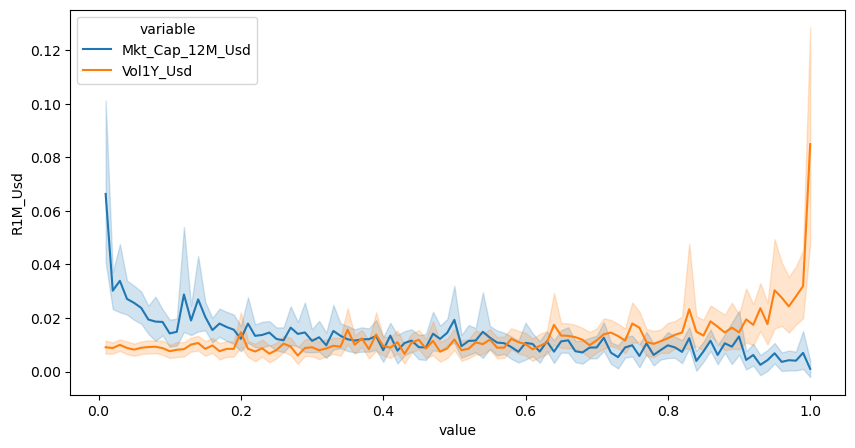

In [13]:
plt.figure(figsize=(10,5))
sns.lineplot(data = unpivoted_data_ml, y='R1M_Usd', x='value', hue='variable'); # Plot from seaborn

#### 3) Autocorrelation of features

In [14]:
cols = ['stock_id'] + features
data_hist_acf=pd.melt(data_ml[cols], id_vars='stock_id').groupby(['stock_id','variable']).apply(lambda x: x['value'].autocorr(lag=1))

C:\Users\ferna\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ferna\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\ferna\AppData\Local\Temp\ipykernel_7384\4156918521.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_hist_acf=pd.melt(data_ml[cols], id_vars='stock_id').groupby(['stock_id','variable']).apply(lambda x: x['value'].autocorr(lag=1))


In [15]:
# pd.melt(data_ml[cols], id_vars='stock_id')
# pd.melt(data_ml[cols], id_vars='stock_id').groupby(['stock_id','variable']).mean()
data_hist_acf

stock_id  variable                      
1         Advt_3M_Usd                       0.958424
          Advt_6M_Usd                       0.969035
          Asset_Turnover                    0.825649
          Bb_Yld                            0.606740
          Bv                                0.998723
                                              ...   
1212      Total_Debt                        0.849388
          Total_Debt_Capital                0.941931
          Total_Liabilities_Total_Assets    0.969583
          Vol1Y_Usd                         0.756909
          Vol3Y_Usd                         0.853401
Length: 110952, dtype: float64

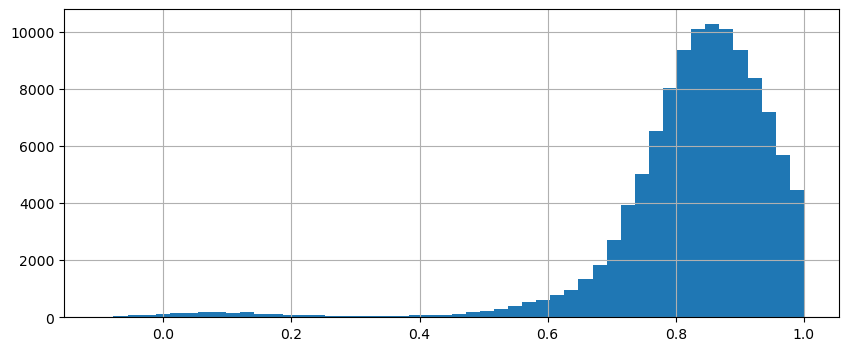

In [16]:
plt.figure(figsize=(10,4))
data_hist_acf.hist(bins=50,range=[-0.1,1]); # Features of each stock_id have high ACF(1). 
# Check full acf - Indicative of nonstationarity vs high memory for some features?

### Additional code and results

In [17]:
length = 100
x      = np.exp(np.sin(np.arange(1,length)))
data   = pd.DataFrame(data=x,columns=['X'])
data.reset_index(inplace=True)

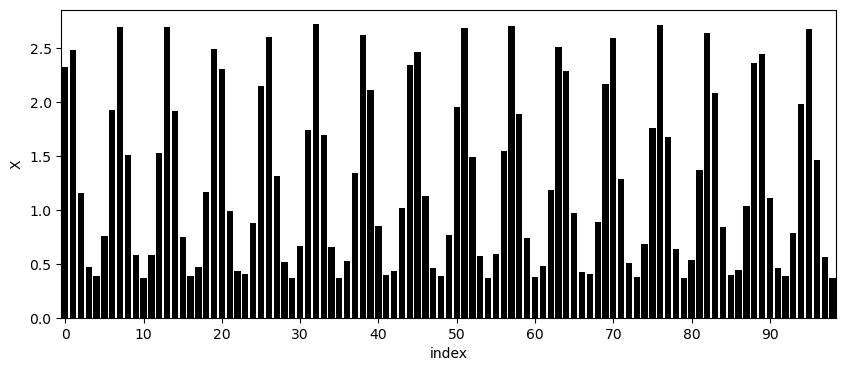

In [18]:
plt.figure(figsize=(10,4))                               # resizing figure
sns.barplot(y="X", data=data, x="index", color='black'); # Plot from Seaborn
plt.xticks(data['index'][::10]);                         # reshape the xtick every 10 observations

In [19]:
from statsmodels.distributions.empirical_distribution import ECDF # to use the ECDF built in function
def norm_0_1(x):
    return (x-np.min(x))/(np.max(x)-np.min(x))
def norm_unif(x):
    return (ECDF(x)(x))
def norm_standard(x):
    return (x- np.mean(x))/np.std(x)

In [20]:
# ensembling numpy arrays into a dict and then a pd dataframe
data_norm=pd.DataFrame.from_dict(dict(index=np.arange(1,length), 
                                      norm_0_1=norm_0_1(x), 
                                      norm_standard=norm_standard(x),
                                      norm_unif=norm_unif(x)))
data_norm.set_index('index',inplace=True)
data_norm.head(4)

,norm_0_1,norm_standard,norm_unif
index,,,
1,0.830537,1.266620,0.818182
2,0.899809,1.463604,0.868687
3,0.333458,-0.146881,0.545455
4,0.043095,-0.972561,0.232323


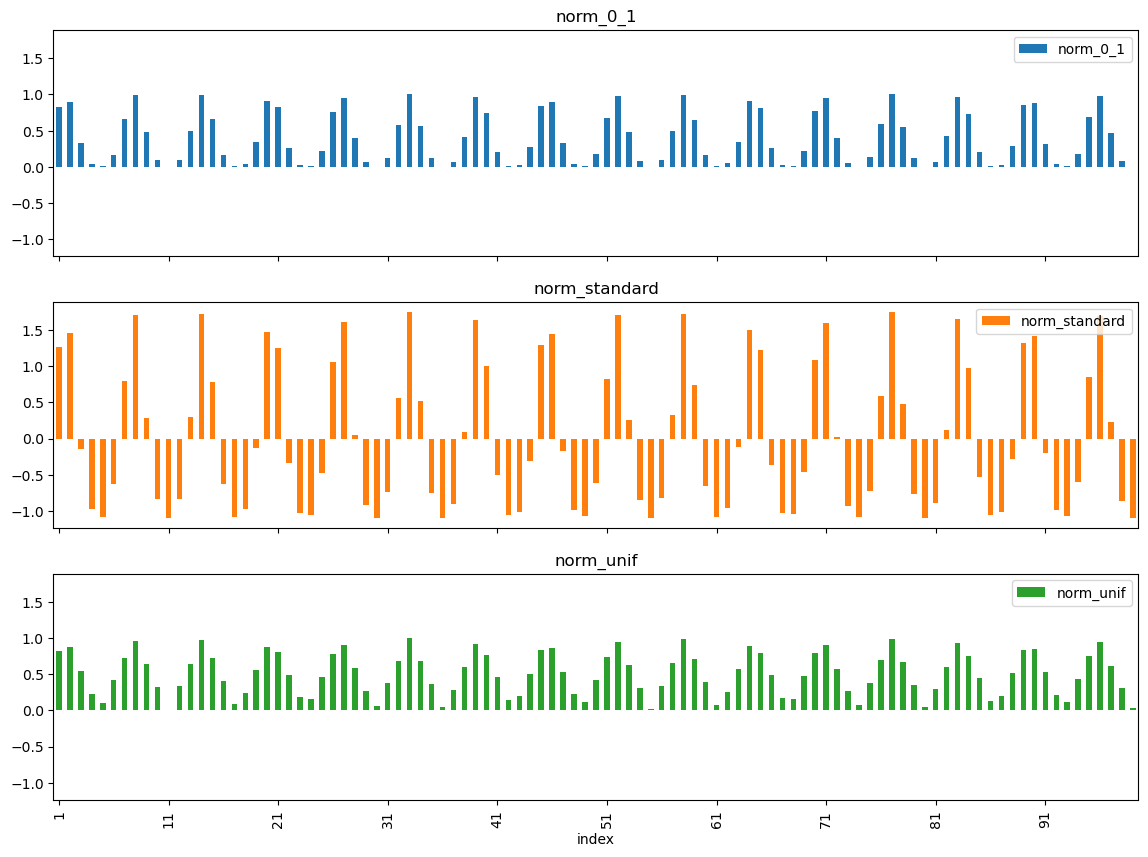

In [21]:
data_norm.plot.bar(figsize=(14,10), subplots=True, sharey=True, sharex=True); # Plot
plt.xticks(data['index'][::10]);   # reshape the xtick every 10 observations

<Axes: ylabel='Frequency'>

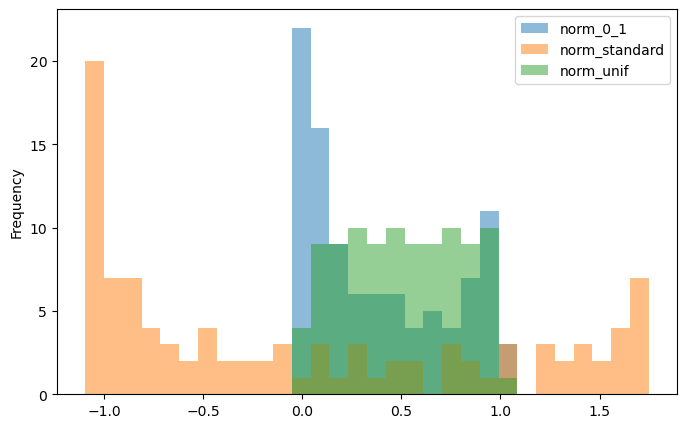

In [22]:
data_norm.plot.hist(alpha=0.5, bins = 30, figsize = (8,5))

# Exercises

### Exercise 1
Pick one macroeconomic variable from the FRED website and use it to expand the number of predictors using formula 4.3

In [23]:
from fredapi import Fred

fred = Fred(api_key=fred_api_key)
ff = fred.get_series("FEDFUNDS")
ff = ff.reset_index()
ff.rename(columns = {'index':'date', 0:'ff'},inplace=True)

In [24]:
ff = ff.set_index('date').resample('ME').last().reset_index()
ff

,date,ff
0,1954-07-31,0.80
1,1954-08-31,1.22
2,1954-09-30,1.07
3,1954-10-31,0.85
4,1954-11-30,0.83
...,...,...
862,2026-05-31,3.63
863,2026-06-30,3.63
864,2026-07-31,3.63
865,2026-08-31,3.63


In [25]:
temp = data_ml.merge(ff,on='date') #inner join
print(temp.shape[0], temp.shape[1])

268336 102


In [26]:
temp.isna().sum(axis = 0)

stock_id        0
date            0
Advt_12M_Usd    0
Advt_3M_Usd     0
Advt_6M_Usd     0
               ..
R6M_Usd         0
R12M_Usd        0
R1M_Usd_C       0
R12M_Usd_C      0
ff              0
Length: 102, dtype: int64

In [27]:
def macro_features(X, z):
    X_tilde = X.apply(lambda x: x*z)
    X_tilde.columns = [x + z.name for x in X_tilde.columns]
    X_tilde = X_tilde.apply(norm_unif) # need to uniformize transformed data
    return(X_tilde)

In [28]:
X_temp = temp.iloc[:,3:95]
z_temp = temp.loc[:,'ff']

In [29]:
df = pd.concat([temp,macro_features(X_temp,z_temp)],axis = 1)
df.head(3)

,stock_id,date,Advt_12M_Usd,Advt_3M_Usd,Advt_6M_Usd,Asset_Turnover,Bb_Yld,Bv,Capex_Ps_Cf,Capex_Sales,...,Share_Turn_6Mff,Taff,Tev_Less_Mktcapff,Tot_Debt_Revff,Total_Capitalff,Total_Debtff,Total_Debt_Capitalff,Total_Liabilities_Total_Assetsff,Vol1Y_Usdff,Vol3Y_Usdff
0,13,2006-12-31,0.25,0.33,0.27,0.22,0.33,0.01,0.13,0.84,...,0.000224,0.000231,0.000224,0.000235,0.000235,0.000235,0.000224,0.000231,0.000224,0.000224
1,13,2007-01-31,0.25,0.32,0.28,0.22,0.40,0.01,0.13,0.84,...,0.000224,0.000231,0.000224,0.000235,0.000235,0.000235,0.000224,0.000231,0.000224,0.000224
2,13,2007-02-28,0.26,0.30,0.30,0.22,0.15,0.01,0.13,0.84,...,0.000224,0.000231,0.000224,0.000235,0.000235,0.000235,0.000224,0.000231,0.000224,0.000224


### Exercise 2: Create a new categorical label using formulas 4.2 and 4.4

In [30]:
# vix data
vix = fred.get_series("VIXCLS")
vix = vix.resample('ME').last()
vix = vix.reset_index()
vix.rename(columns = {'index':'date',0:'vix'},inplace=True)
vix.head(3)

,date,vix
0,1990-01-31,25.36
1,1990-02-28,21.99
2,1990-03-31,19.73


In [31]:
df_ret = data_ml[['stock_id','date','R1M_Usd']]

In [32]:
delta    = 0.02
vix_mean = vix.loc[:,'vix'].mean()
r_plus   = 0.05
r_minus  = -0.05

In [33]:
r_plux_vix  = r_plus * np.exp(delta * (vix['vix'] - vix_mean))
r_minus_vix = r_minus * np.exp(delta * (vix['vix'] - vix_mean))
vix['plus_vix'] = r_plux_vix
vix['minus_vix'] = r_minus_vix

<Axes: >

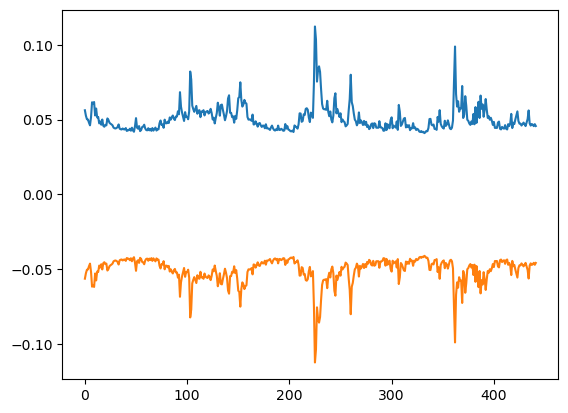

In [34]:
r_plux_vix.plot()
r_minus_vix.plot()

In [35]:
df_vix = df_ret.merge(vix,on='date',how='left')
df_vix.head()

,stock_id,date,R1M_Usd,vix,plus_vix,minus_vix
0,13,2006-12-31,0.089,11.56,0.042704,-0.042704
1,13,2007-01-31,0.039,10.42,0.041742,-0.041742
2,13,2007-02-28,-0.012,15.42,0.046132,-0.046132
3,17,2015-03-31,0.174,15.29,0.046012,-0.046012
4,17,2015-04-30,-0.106,14.55,0.045336,-0.045336


In [36]:
df_vix['R1M_Usd_class'] = np.where(df_vix['R1M_Usd']>df_vix['plus_vix'],1,
                                    np.where(((df_vix['R1M_Usd']<=df_vix['plus_vix']) & (df_vix['R1M_Usd']>=df_vix['minus_vix'])),0,-1))

In [37]:
df_vix

,stock_id,date,R1M_Usd,vix,plus_vix,minus_vix,R1M_Usd_class
0,13,2006-12-31,0.089,11.56,0.042704,-0.042704,1
1,13,2007-01-31,0.039,10.42,0.041742,-0.041742,0
2,13,2007-02-28,-0.012,15.42,0.046132,-0.046132,0
3,17,2015-03-31,0.174,15.29,0.046012,-0.046012,1
4,17,2015-04-30,-0.106,14.55,0.045336,-0.045336,-1
...,...,...,...,...,...,...,...
268331,1205,2004-05-31,-0.029,15.50,0.046205,-0.046205,0
268332,1205,2004-07-31,0.028,15.32,0.046039,-0.046039,0
268333,1205,2004-08-31,0.011,15.29,0.046012,-0.046012,0
268334,1205,2004-09-30,0.045,13.34,0.044252,-0.044252,1


<Axes: xlabel='date'>

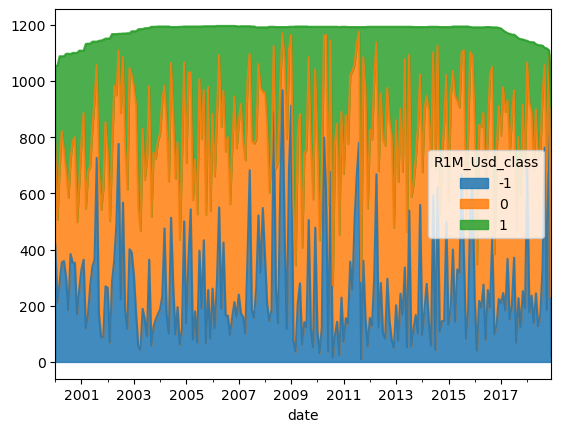

In [38]:
df_vix.groupby(["date", "R1M_Usd_class"]).size().unstack(fill_value=0).plot(kind="area", stacked=True, alpha=0.85)

## Exercise 3

<Axes: ylabel='Frequency'>

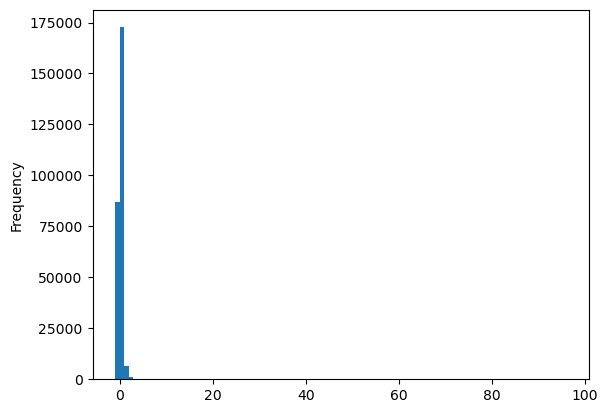

In [39]:
df_out = data_ml[['stock_id', 'date', 'R12M_Usd']]
df_out["R12M_Usd"].plot(kind="hist",bins = 100)

In [40]:
df_out.iloc[df_out["R12M_Usd"].argmax(),:]

stock_id                    683
date        2009-02-28 00:00:00
R12M_Usd                 95.972
Name: 64782, dtype: object

In [41]:
df_out[(df_out['stock_id'] == 683) & (df_out['date'].dt.year == 2009)].sort_values('date')

,stock_id,date,R12M_Usd
64781,683,2009-01-31,37.520
64782,683,2009-02-28,95.972
1701,683,2009-03-31,64.830
1702,683,2009-04-30,21.967
1703,683,2009-05-31,15.691
1704,683,2009-06-30,11.245
1705,683,2009-07-31,14.089
1706,683,2009-08-31,8.164
1707,683,2009-09-30,9.449
1708,683,2009-10-31,-0.209
